## ML Classical Baselines

In [1]:
import importlib
from pathlib import Path

from IPython.display import display

import utils.ml_pipeline as ml_pipeline
import utils.plots as ml_plots

importlib.reload(ml_pipeline)
importlib.reload(ml_plots)

from utils.cache import get_results_path
from utils.ml_pipeline import (
    best_confusion_predictions,
    load_all_predictions,
    load_feature_dataframes,
    load_lovo_summary_tables,
    load_params_lookup,
    load_raw_csi_data,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
    plot_block_vs_lovo_position_accuracy,
    plot_lovo_fold_spread,
    run_global_baselines,
    run_optional_grid_search,
    save_analysis_tables,
    save_lovo_analysis_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)

#### Project Configurations

In [2]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "data"
CALIBRATION_MODE = "rssi"

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "apply_agc_compensation": False,
    "agc_reference": "median",
    "filter_method": "none",
    "filter_window": 5,
    "normalization": "none",
    "epsilon": 1e-8,
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 60,
    "overlap_size": 30,
    "calibrate": False,
    "require_all_esps": False,
}

MODELS_TO_RUN = ("RF", "KNN", "SVM")
BANDS_TO_RUN = ("2.4 GHz", "5 GHz", "Fusion")
SPLIT_MODES = ("block", "lovo")      # "random" remains available for contamination demonstrations.
RUN_GRID_SEARCH = False
FORCE_RETRAIN = False
SAVE_PREDICTIONS = True
SVM_KERNEL = "rbf"            # "rbf" | "linear"
N_JOBS = -1

BLOCK_COUNT = 10
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0
SVM_FUSION_FALLBACK_SECONDS = 30 * 60

CONFUSION_DATASET = "Fusion"
CONFUSION_MODEL = "best"      # "best", "RF", "KNN", or "SVM"

SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)
results_dir = get_results_path(preproc_opts, feat_opts)
summary_dir = results_dir / "summary"
tables_dir = results_dir / "tables"
tuning_dir = results_dir / "tuning"
plots_dir = results_dir / "plots"
for directory in (summary_dir, tables_dir, tuning_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")

## Raw Data

In [3]:
magnitude_data, agc_gain_data, csv_diagnostics = load_raw_csi_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
)

Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 18


#### Feature Dataframes

In [4]:
feature_dataframes = load_feature_dataframes(
    magnitude_data,
    agc_gain_data,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    bands_to_run=BANDS_TO_RUN,
)
del magnitude_data, agc_gain_data

[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\2_4ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\5ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\fusion.parquet
2.4 GHz: 18080 windows, 2408 columns
5 GHz: 19673 windows, 3368 columns
Fusion: 18038 windows, 5768 columns


#### Model Parameters

In [5]:
TUNED_SUMMARY_PATH = tuning_dir / "tuned_summary.csv"
GRID_LOG_PATH = tuning_dir / "full_grid_log.csv"

params_lookup = load_params_lookup(
    TUNED_SUMMARY_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
)
for key, value in params_lookup.items():
    print(f"{key}: {value}")

('RF', '2.4 GHz'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', '5 GHz'): {'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('RF', 'Fusion'): {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
('KNN', '2.4 GHz'): {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'}
('KNN', '5 GHz'): {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'}
('KNN', 'Fusion'): {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'}
('SVM', '2.4 GHz'): {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}
('SVM', '5 GHz'): {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}
('SVM', 'Fusion'): {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}


##### Optional Grid Search

In [6]:
grid_ran = run_optional_grid_search(
    feature_dataframes,
    run_grid_search=RUN_GRID_SEARCH,
    tuned_summary_path=TUNED_SUMMARY_PATH,
    grid_log_path=GRID_LOG_PATH,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    svm_kernel=SVM_KERNEL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
if grid_ran:
    raise SystemExit("RUN_GRID_SEARCH=True completed; set it to False before running experiments.")

#### Global 52-Class Baselines

In [7]:
global_summary, global_predictions_by_key = run_global_baselines(
    feature_dataframes,
    params_lookup=params_lookup,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    n_jobs=N_JOBS,
    results_dir=results_dir,
    summary_dir=summary_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    force_retrain=FORCE_RETRAIN,
    save_predictions=SAVE_PREDICTIONS,
    svm_fallback_seconds=SVM_FUSION_FALLBACK_SECONDS,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
display(global_summary)

[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\2_4ghz__rf__block.parquet
[LOVO check] 2.4 GHz: every observed position has at least two users.
[LOVO check] 2.4 GHz: held_out_user=01 training covers 53/53 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=02 training covers 53/53 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=03 training covers 53/53 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=04 training covers 53/53 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=05 training covers 53/53 observed positions; singleton-position test windows=0.
[LOVO check] 2.4 GHz: held_out_user=06 training covers 53/53 observed positions; singleton-position test windows=0.
[LOVO] Hyperparameter provenance: reusi

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[predictions] Saved c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\2_4ghz__knn__lovo__user-01.parquet
[LOVO] fold 1/6 done: acc=0.0491 fit=1.2s predict=6.2s wall=7.6s
[LOVO] 2.4 GHz / KNN fold 2/6: held_out_user=02
[predictions] Saved c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\2_4ghz__knn__lovo__user-02.parquet
[LOVO] fold 2/6 done: acc=0.0563 fit=1.1s predict=4.6s wall=5.9s
[LOVO] 2.4 GHz / KNN fold 3/6: held_out_user=03
[predictions] Saved c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\2_4ghz__knn__lovo__user-03.parquet
[LOVO] fold 3/6 done: acc=0.0500 fit=1.0s predict=5.2s wall=6.4s
[LOVO] 2.4 GHz / KNN fold 4/6: held_out_user=04
[predictions] Saved c:\Users\pedro\OneDrive - Universidade de

,dataset,model,split,n_estimators,max_features,max_depth,min_samples_split,min_samples_leaf,position_accuracy,macro_f1,...,n_folds,n_test_windows,min_fold_position_accuracy,max_fold_position_accuracy,n_neighbors,weights,metric,kernel,C,gamma
0,2.4 GHz,RF,block,500.0,log2,NaN,2.0,1.0,0.872599,0.873381,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.4 GHz,RF,lovo,500.0,log2,NaN,2.0,1.0,0.128097,0.111079,...,6.0,18080.0,0.028539,0.269603,NaN,NaN,NaN,NaN,NaN,NaN
2,2.4 GHz,KNN,block,NaN,NaN,NaN,NaN,NaN,0.498177,0.513892,...,NaN,NaN,NaN,NaN,5.0,distance,euclidean,NaN,NaN,NaN
3,2.4 GHz,KNN,lovo,NaN,NaN,NaN,NaN,NaN,0.072351,0.070770,...,6.0,18080.0,0.028158,0.126466,5.0,distance,euclidean,NaN,NaN,NaN
4,2.4 GHz,SVM,block,NaN,NaN,NaN,NaN,NaN,0.750547,0.753826,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rbf,10.0,scale
5,2.4 GHz,SVM,lovo,NaN,NaN,NaN,NaN,NaN,0.105942,0.094619,...,6.0,18080.0,0.014079,0.231899,NaN,NaN,NaN,rbf,10.0,scale
6,5 GHz,RF,block,500.0,sqrt,NaN,2.0,1.0,0.887609,0.887741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5 GHz,RF,lovo,500.0,sqrt,NaN,2.0,1.0,0.114028,0.087106,...,6.0,19673.0,0.048796,0.196126,NaN,NaN,NaN,NaN,NaN,NaN
8,5 GHz,KNN,block,NaN,NaN,NaN,NaN,NaN,0.292609,0.298800,...,NaN,NaN,NaN,NaN,5.0,distance,euclidean,NaN,NaN,NaN
9,5 GHz,KNN,lovo,NaN,NaN,NaN,NaN,NaN,0.039304,0.032974,...,6.0,19673.0,0.021001,0.054479,5.0,distance,euclidean,NaN,NaN,NaN


#### Analysis Tables

In [8]:
all_global_predictions = load_all_predictions(
    results_dir,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
)

master_table = master_results_table(
    all_global_predictions,
    summary_path=summary_dir / "global_summary.csv",
)
per_room_table = per_room_position_accuracy_table(all_global_predictions)
save_analysis_tables(master_table, per_room_table, tables_dir=tables_dir)

display(master_table)
display(per_room_table)

[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\2_4ghz__rf__block.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\2_4ghz__rf__lovo.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\5ghz__rf__block.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\5ghz__rf__lovo.parquet
[predictions cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\predictions\fusion__rf__block.parquet
[predictions cache hit] c:\User

,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,samples,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,KNN,2.4 GHz,block,0.498177,0.513892,0.866764,1.819562,0.000000,3.250082,5.099020,4113.0,0.000000,0.000000,0.000000,cached_predictions
1,KNN,2.4 GHz,lovo,0.072351,0.070770,0.544745,4.703450,4.105736,5.740364,9.812016,18080.0,6.540515,31.015969,39.874311,KNeighborsClassifier
2,RF,2.4 GHz,block,0.872599,0.873381,0.980063,0.298359,0.000000,1.122499,1.000000,4113.0,0.000000,0.000000,0.000000,cached_predictions
3,RF,2.4 GHz,lovo,0.128097,0.111079,0.606253,4.243071,3.481058,5.386334,9.250895,18080.0,439.985012,4.562350,450.895655,RandomForestClassifier
4,SVM,2.4 GHz,block,0.750547,0.753826,0.955507,0.702035,0.000000,1.828812,2.828427,4113.0,0.000000,0.000000,0.000000,cached_predictions
5,SVM,2.4 GHz,lovo,0.105942,0.094619,0.600391,4.334775,3.717241,5.401774,9.133732,18080.0,1148.198685,793.062117,1942.738895,SVC
6,KNN,5 GHz,block,0.292609,0.298800,0.813478,2.339597,2.000000,3.421774,5.575347,4600.0,0.000000,0.000000,0.000000,cached_predictions
7,KNN,5 GHz,lovo,0.039304,0.032974,0.478257,4.753797,4.275188,5.578237,8.988807,19673.0,13.691803,48.710622,64.798564,KNeighborsClassifier
8,RF,5 GHz,block,0.887609,0.887741,0.994130,0.211553,0.000000,0.757038,1.000000,4600.0,0.000000,0.000000,0.000000,cached_predictions
9,RF,5 GHz,lovo,0.114028,0.087106,0.549425,3.883255,3.422610,4.793196,7.857799,19673.0,2404.374179,4.335785,2414.510561,RandomForestClassifier


,model,dataset,split,true_room,samples,position_accuracy
0,KNN,2.4 GHz,block,0,80,0.550000
1,KNN,2.4 GHz,block,1,2638,0.449583
2,KNN,2.4 GHz,block,2,768,0.600260
3,KNN,2.4 GHz,block,3,627,0.570973
4,KNN,2.4 GHz,lovo,0,358,0.013966
...,...,...,...,...,...,...
67,SVM,Fusion,block,3,622,0.852090
68,SVM,Fusion,lovo,0,356,0.005618
69,SVM,Fusion,lovo,1,11563,0.113033
70,SVM,Fusion,lovo,2,3360,0.123810


#### LOVO cross-user analysis


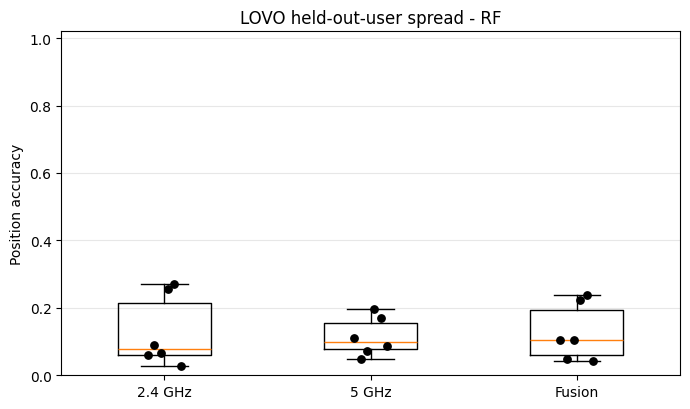

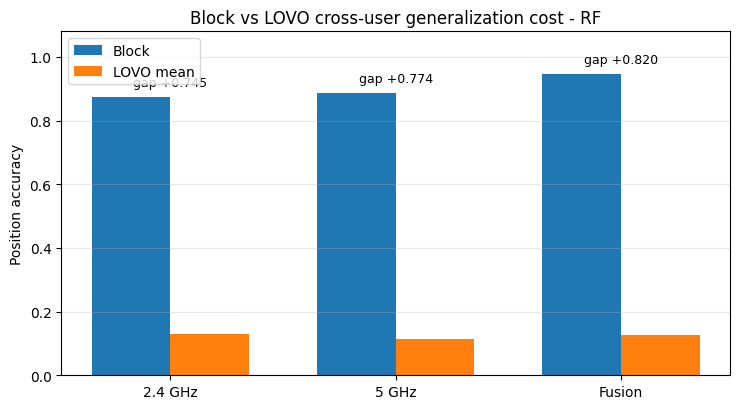

,model,dataset,position_accuracy_mean_std,macro_f1_mean_std,room_accuracy_mean_std,mean_distance_error_mean_std,median_distance_error_mean_std,rmse_distance_error_mean_std,p90_distance_error_mean_std
0,KNN,2.4 GHz,0.0724 +/- 0.0421,0.0708 +/- 0.0479,0.5447 +/- 0.1095,4.7035 +/- 0.3683,4.1057 +/- 0.6095,5.7404 +/- 0.4782,9.8120 +/- 1.1266
1,RF,2.4 GHz,0.1281 +/- 0.1057,0.1111 +/- 0.0999,0.6063 +/- 0.1081,4.2431 +/- 0.8034,3.4811 +/- 1.4348,5.3863 +/- 0.7479,9.2509 +/- 1.8722
2,SVM,2.4 GHz,0.1059 +/- 0.0917,0.0946 +/- 0.0978,0.6004 +/- 0.1122,4.3348 +/- 0.5265,3.7172 +/- 0.9047,5.4018 +/- 0.6736,9.1337 +/- 1.7346
3,KNN,5 GHz,0.0393 +/- 0.0129,0.0330 +/- 0.0151,0.4783 +/- 0.1272,4.7538 +/- 0.5555,4.2752 +/- 0.6836,5.5782 +/- 0.6686,8.9888 +/- 1.4972
4,RF,5 GHz,0.1140 +/- 0.0574,0.0871 +/- 0.0531,0.5494 +/- 0.1117,3.8833 +/- 0.3879,3.4226 +/- 0.3780,4.7932 +/- 0.3632,7.8578 +/- 0.5493
5,SVM,5 GHz,0.0817 +/- 0.0368,0.0662 +/- 0.0396,0.5940 +/- 0.1628,4.3138 +/- 0.6725,3.9054 +/- 0.6192,5.1883 +/- 0.8959,8.5291 +/- 1.7619
6,KNN,Fusion,0.0610 +/- 0.0402,0.0558 +/- 0.0466,0.5050 +/- 0.1068,4.7531 +/- 0.1688,4.2206 +/- 0.4726,5.6892 +/- 0.3620,9.3245 +/- 1.2898
7,RF,Fusion,0.1264 +/- 0.0847,0.1085 +/- 0.0812,0.5795 +/- 0.0859,3.9055 +/- 0.4451,3.5999 +/- 0.8058,4.8200 +/- 0.2728,7.9581 +/- 0.8955
8,SVM,Fusion,0.1023 +/- 0.0921,0.0871 +/- 0.1012,0.6236 +/- 0.0677,4.3097 +/- 0.2280,3.6910 +/- 0.6721,5.3288 +/- 0.4518,9.0868 +/- 1.3099


,model,dataset,held_out_user,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,samples,n_test_windows,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,RF,2.4 GHz,1,0.059895,0.042608,0.621179,4.294589,4.000000,5.098278,8.062258,3239.0,3239,71.965832,0.599749,73.004586,RandomForestClassifier
1,RF,2.4 GHz,2,0.089448,0.071565,0.665968,4.198738,4.000000,4.959716,7.280110,2862.0,2862,70.646166,1.078206,71.976939,RandomForestClassifier
2,RF,2.4 GHz,3,0.066583,0.059558,0.387934,5.485204,5.000000,6.635340,11.045361,3199.0,3199,67.543517,0.648511,68.387549,RandomForestClassifier
3,RF,2.4 GHz,4,0.254517,0.222621,0.657686,4.020352,2.000000,5.952776,12.000000,3155.0,3155,82.514223,0.900661,83.756320,RandomForestClassifier
4,RF,2.4 GHz,5,0.269603,0.252180,0.645312,2.986970,1.414214,4.686220,9.055385,2997.0,2997,78.407522,0.762846,79.418690,RandomForestClassifier
5,RF,2.4 GHz,6,0.028539,0.017941,0.659437,4.472574,4.472136,4.985672,8.062258,2628.0,2628,68.907751,0.572378,69.673944,RandomForestClassifier
18,RF,5 GHz,1,0.109291,0.079812,0.678380,4.100995,3.162278,5.138129,8.246211,3358.0,3358,335.402773,0.394593,335.923438,RandomForestClassifier
19,RF,5 GHz,2,0.048796,0.030374,0.640210,3.996284,3.605551,4.662272,7.280110,3238.0,3238,323.104386,0.461079,323.709812,RandomForestClassifier
20,RF,5 GHz,3,0.073403,0.049757,0.379300,4.267827,4.000000,5.228587,8.424887,3256.0,3256,298.708115,0.939646,299.953153,RandomForestClassifier
21,RF,5 GHz,4,0.196126,0.165037,0.603208,3.530087,3.000000,4.636133,8.062258,3304.0,3304,664.367492,1.097736,665.841691,RandomForestClassifier


In [9]:
if "lovo" in SPLIT_MODES:
    lovo_per_fold, lovo_summary = load_lovo_summary_tables(summary_dir)
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)
    save_lovo_analysis_table(lovo_table, tables_dir=tables_dir)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('lovo rf fold spread')}.pdf",
    )
    plot_block_vs_lovo_position_accuracy(
        globals().get("global_summary", master_table),
        lovo_summary,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('block vs lovo rf position accuracy')}.pdf",
    )

    display(lovo_table)
    display(lovo_per_fold.loc[lovo_per_fold["model"] == "RF"])
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")

#### Analysis Figures

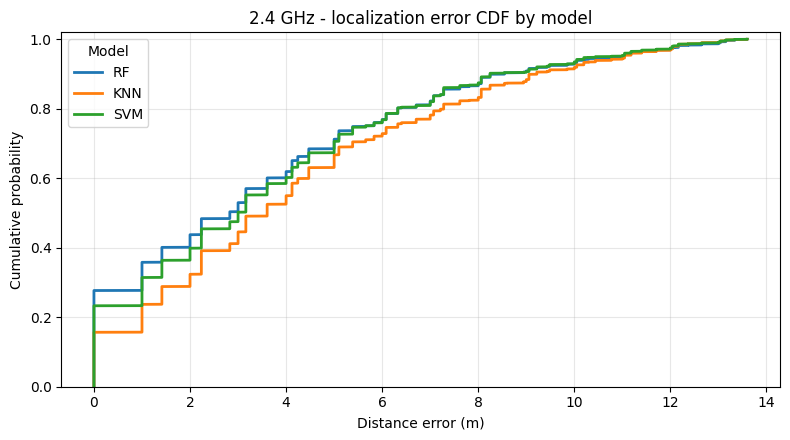

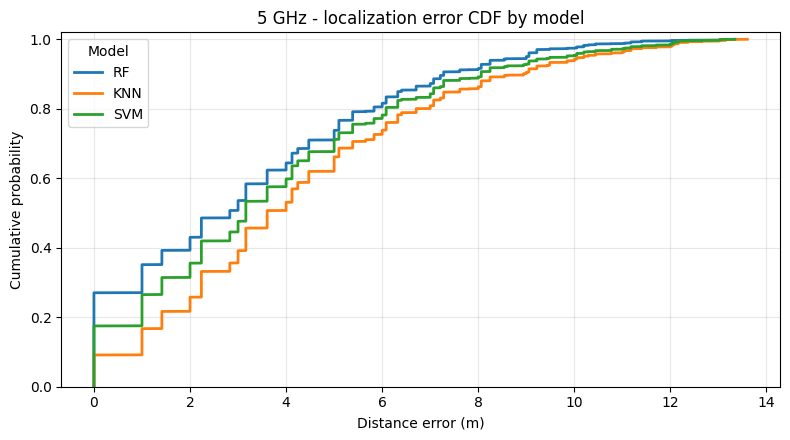

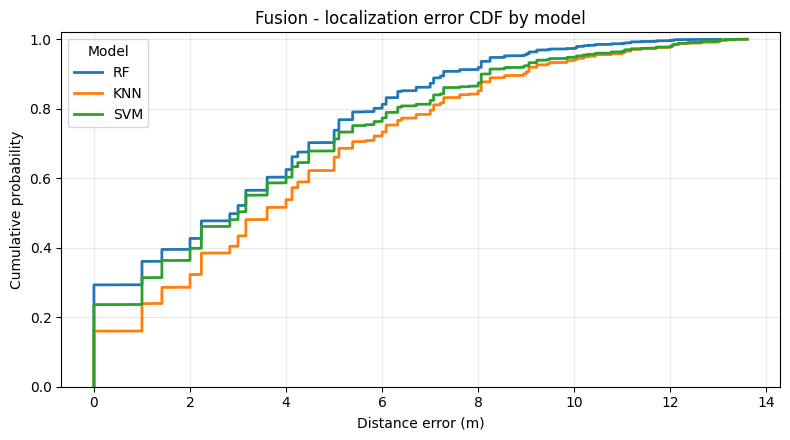

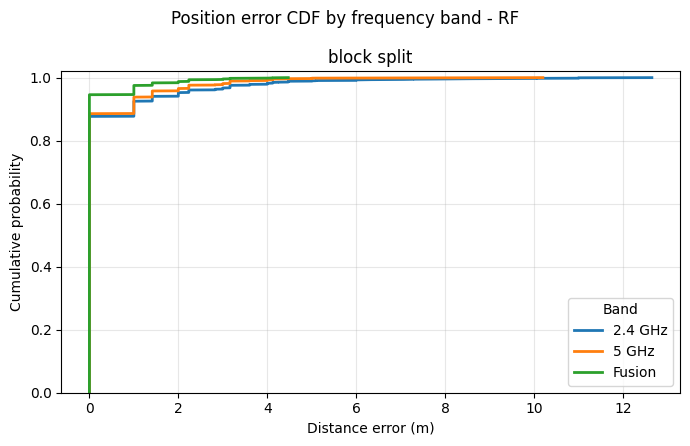

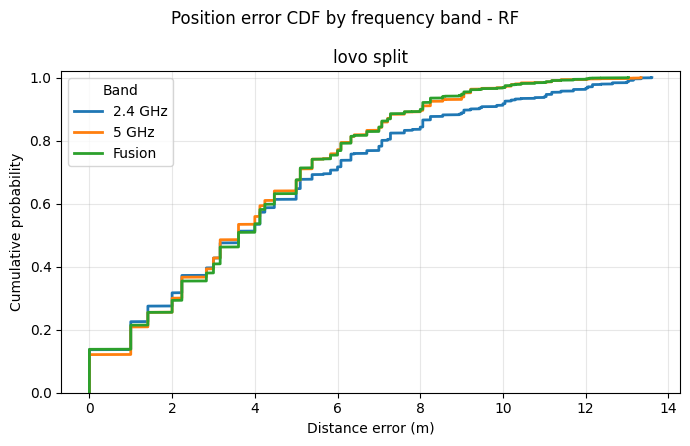

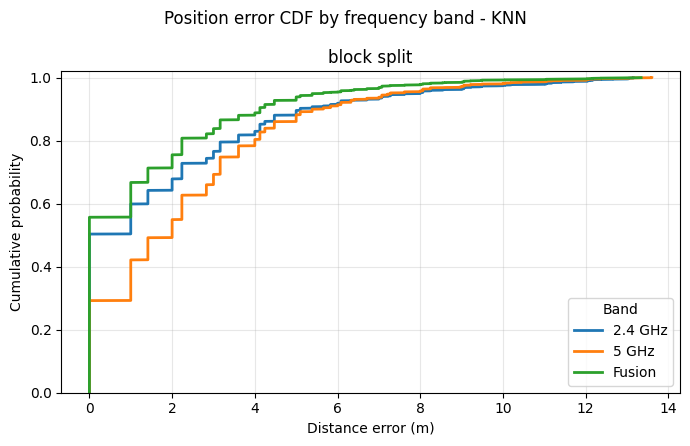

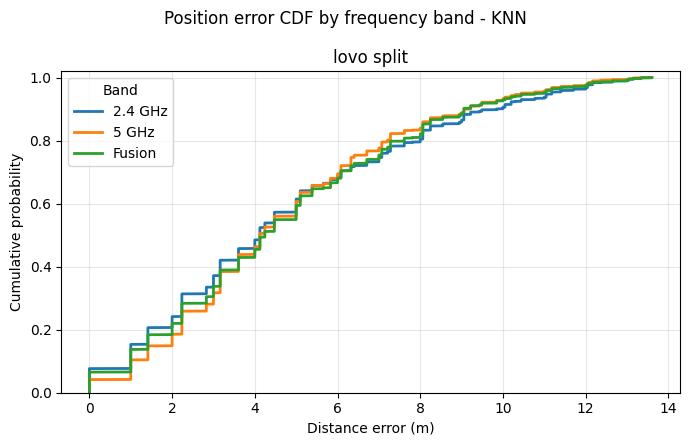

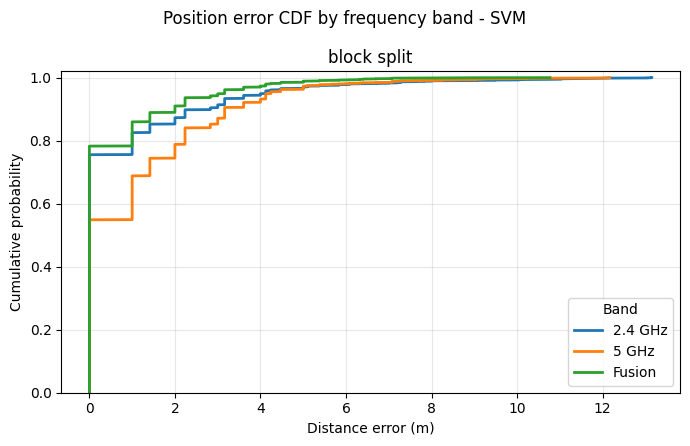

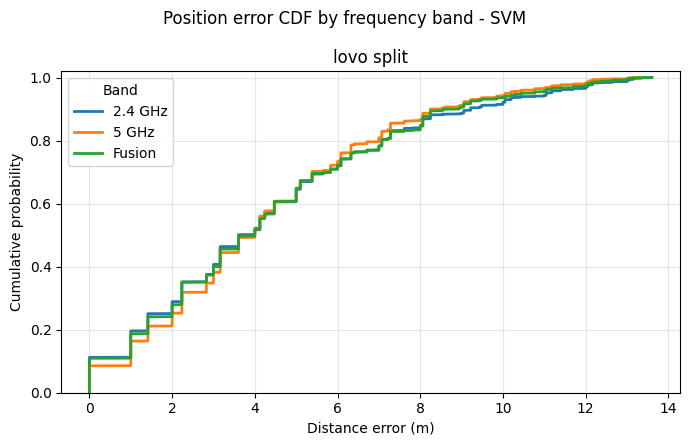

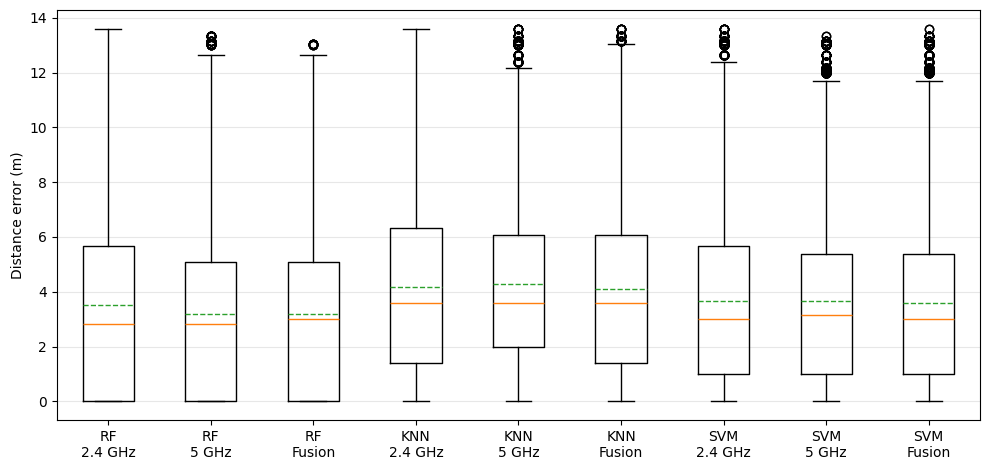

In [10]:
if SHOW_CDF_BY_BAND:
    for band in BANDS_TO_RUN:
        plot_localization_error_cdf_by_model(
            all_global_predictions,
            dataset=band,
            save_path=plots_dir / f"cdf_by_model_{_slugify(band)}.pdf",
        )

if SHOW_CDF_BY_MODEL:
    for model in MODELS_TO_RUN:
        model_predictions = all_global_predictions.loc[all_global_predictions["model"] == model]
        plot_band_error_cdf(
            model_predictions,
            model_label=model,
            split_modes=SPLIT_MODES,
            band_order=BANDS_TO_RUN,
            save_path=plots_dir,
        )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_global_predictions,
        models=MODELS_TO_RUN,
        bands=BANDS_TO_RUN,
        save_path=plots_dir / "boxplot_model_band_distance_error.pdf",
    )

#### Confusion Matrix And Floor Plan

Confusion/floor-plan model: RF on Fusion


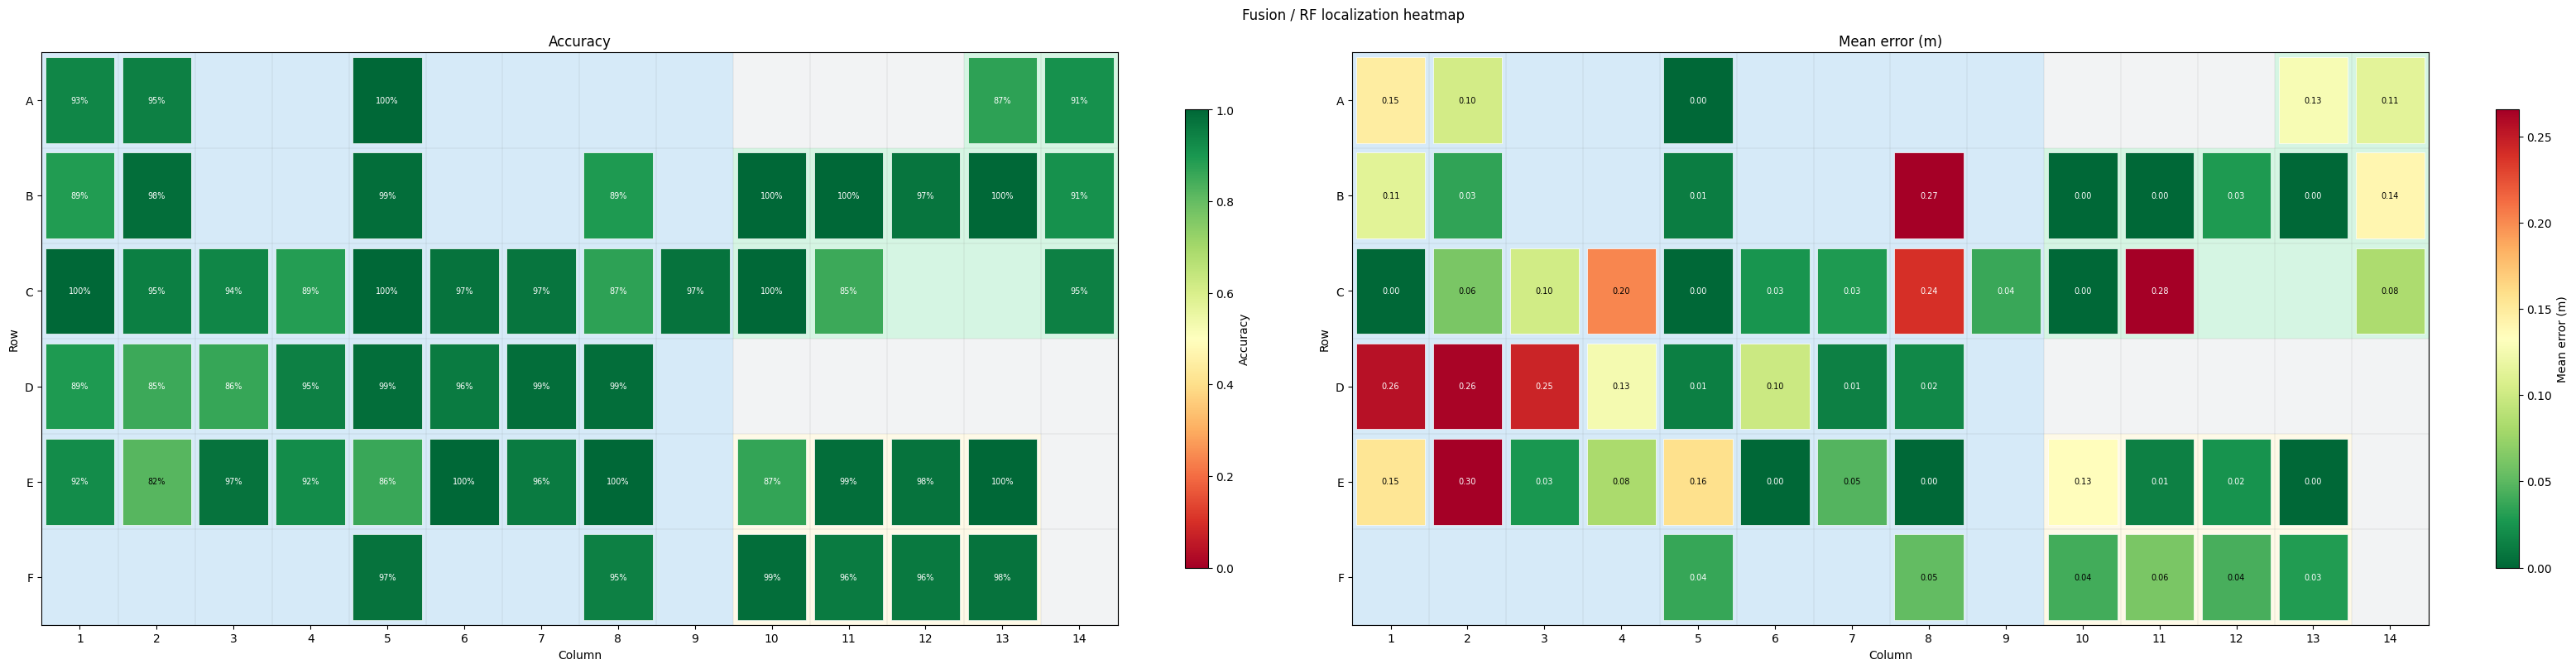

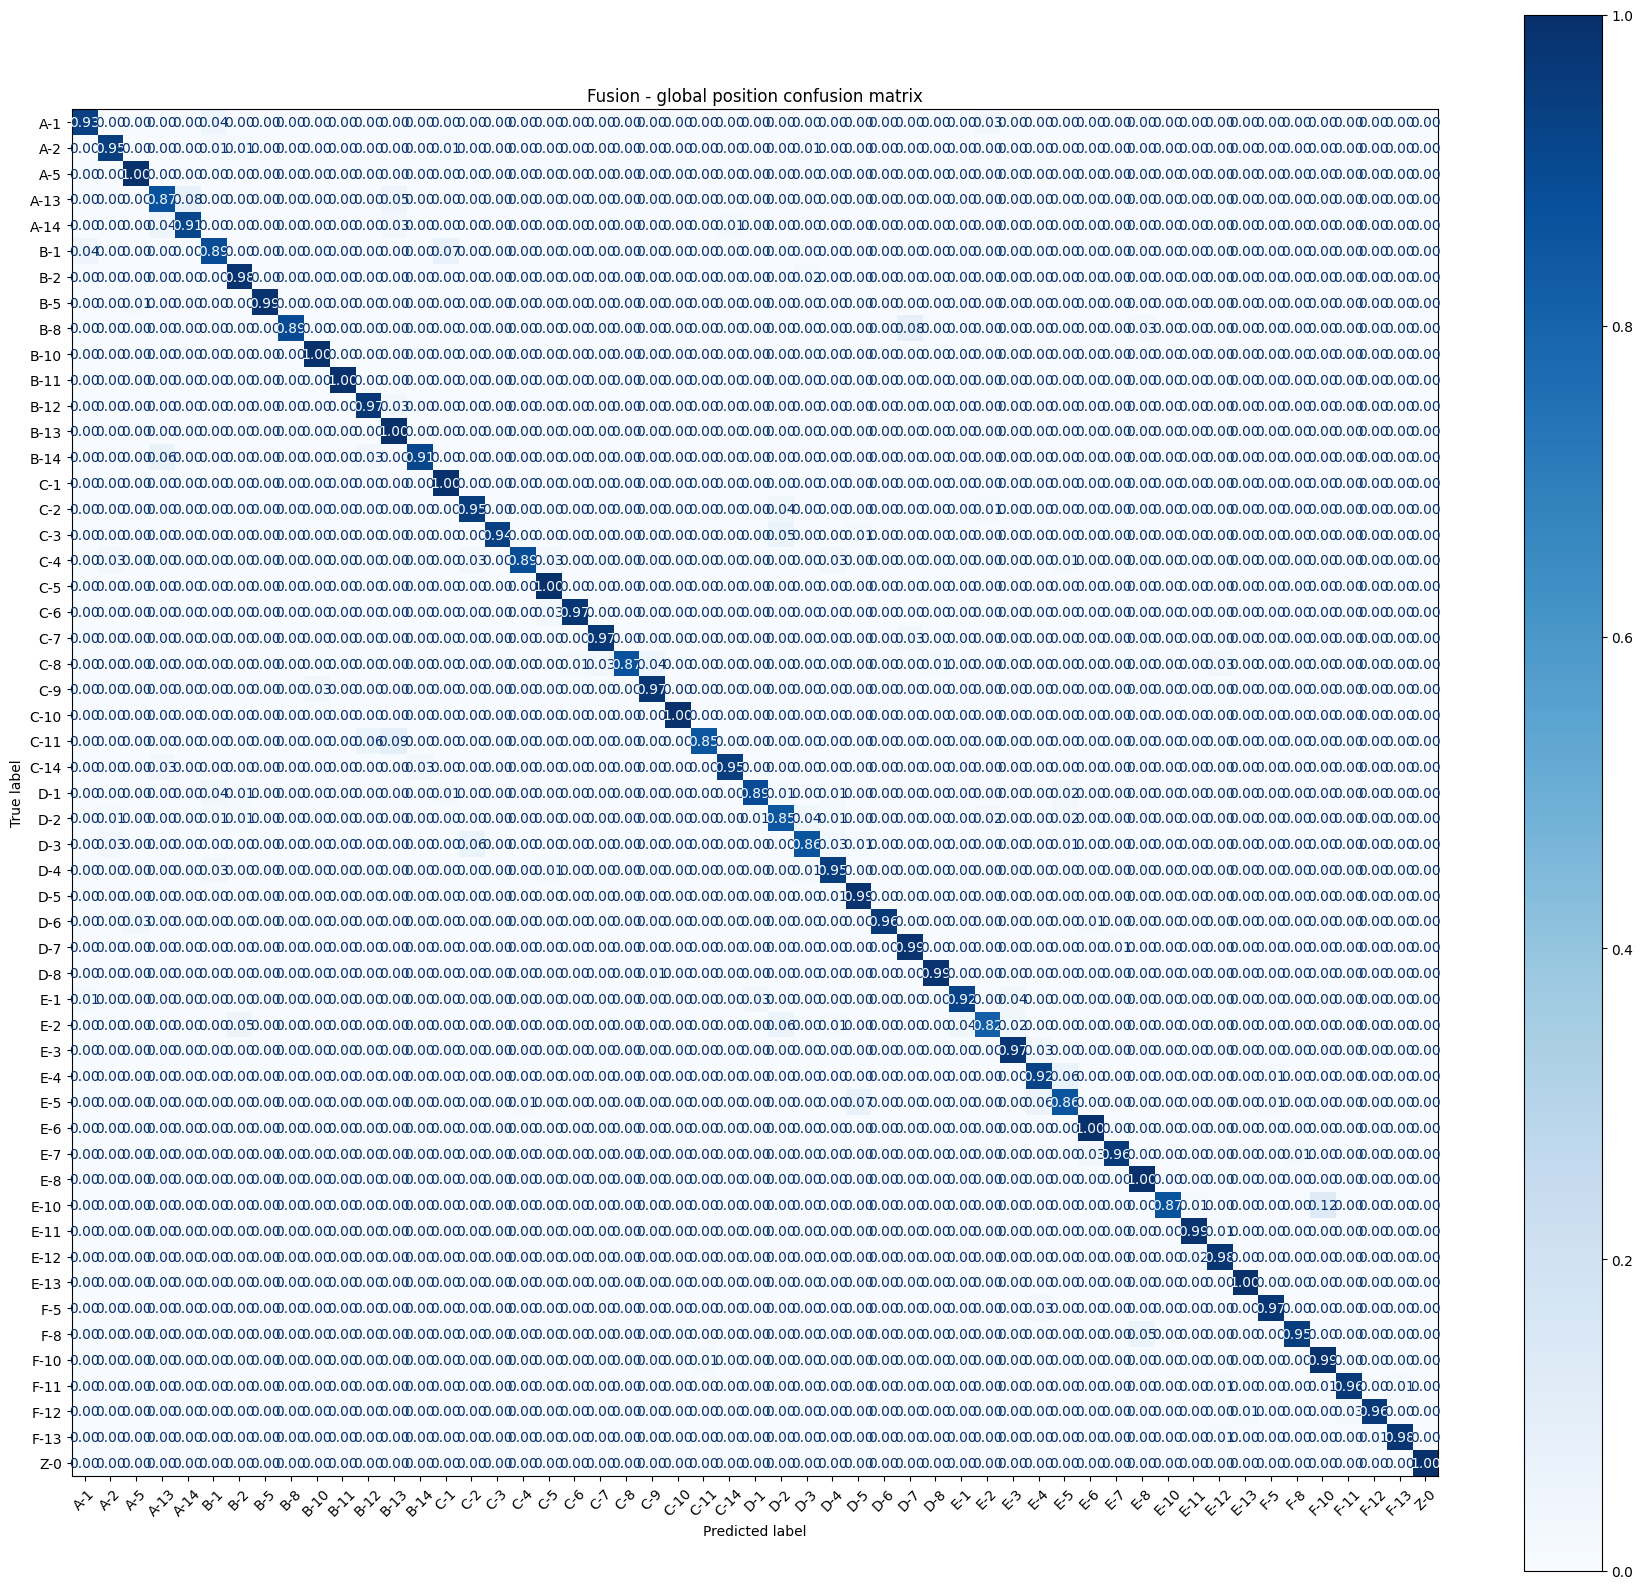

In [11]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_global_predictions,
    master_table,
    dataset=CONFUSION_DATASET,
    model=CONFUSION_MODEL,
)
print(f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET}")

if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=f"{CONFUSION_DATASET} / {confusion_model} localization heatmap",
        save_path=plots_dir / f"floor_plan_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.pdf",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=plots_dir / f"confusion_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.pdf",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = plots_dir / f"confusion_by_room_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )